In [1]:
path = '/home/user/Desktop/diploma'

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import re
import os
import sys

In [3]:
sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import load_documents, annotations_from_jsonl

In [4]:
def highlight_words(text, ranges):
    words = text.split()
    highlighted_text = []
    for i, word in enumerate(words):
        if any(start <= i < end for start, end in ranges):
            highlighted_text.append(f"\033[42m{word}\033[0m")  # yellow background
        else:
            highlighted_text.append(word)
    text = " ".join(highlighted_text)
    for i in range(0, len(text), 500):
        print(text[i:i+500])

In [35]:
def print_experiment_instance(path, task, model, idx):

    os.chdir(path+f'/attacks/{"movie" if task == "movies" else "esnli"}_attacks')
    attack = pd.read_csv(f"{model}_TextFoolerJin2019.csv")

    introspections_path = path + '/introspections/results/analysis'
    sqlite_files = [f for f in os.listdir(introspections_path) if model in f and ('imdb' if task == "movies" else "rte") in f and f.endswith('.sqlite')]
    conn = sqlite3.connect(os.path.join(introspections_path, sqlite_files[0]))
    df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)

    print('\n' + '='*80)
    print(f'\033[1;34mEXPERIMENT: Introspection on {"IMDB" if task == "movies" else "e-Snli"}\033[0m')
    print('='*80)
    print(f'\n\033[1;34mPrinting instance with index {idx}\033[0m')

    print('\n\033[1m1. CLASSIFICATION\033[0m')
    print('→ Prompt: {}'.format(df.iloc[idx]["predict_prompt"].replace("Paragraph","\n\t  Paragraph")))

    classification = df.iloc[idx]["predict"].strip().lower()
    color = "\033[1;32m" if (classification == "positive" or classification == "yes") else "\033[1;31m"
    print(f'→ Classification: {color}{classification.upper()}\033[0m')

    print('\n\033[1m2. ADVERSARIAL ATTACK (TextFoolerJin)\033[0m')
    if task == 'esnli':
        text = attack.iloc[idx]['perturbed_text'].split('.')[1]
        print('→ Perturbed Text:', text)
    else:
        text = attack.iloc[idx]['perturbed_text']
        print('→ Perturbed Text:', text)
    print('Result:', attack.iloc[idx]['original_output'], '→' ,attack.iloc[idx]['perturbed_output'],'Status:', attack.iloc[idx]['result_type'])

    print('\n\033[1m3. COUNTERFACTUAL GENERATION\033[0m')
    for file in sqlite_files:
        conn = sqlite3.connect(os.path.join(introspections_path, file))
        df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)
        variant = file.split('_c-')[1].split('_s')[0] if file.split('_c-')[1].split('_s')[0] else 'default'
        print(f'• Variant: \033[1;36m{variant}\033[0m')
        print(f'  Prompt: {df.iloc[idx]["explain_prompt"]}')
        print(f'  CF Edit: {df.iloc[idx]["explain"]}')
        classification = df.iloc[idx]["explain_predict"].strip().lower()
        color = "\033[1;32m" if (classification == "positive" or classification == "yes") else "\033[1;31m"
        print(f'  CF Classification: {color}{classification.upper()}\033[0m | Faithfulness: {int(df.iloc[idx]["faithful"])}')
        print('-'*60)




# **Datasets**

## **IMDB**

In [13]:
movies_data_root = path + '/eraserbenchmark-master/data/movies'
movies_documents = load_documents(movies_data_root)
movies = annotations_from_jsonl(os.path.join(movies_data_root, 'test.jsonl'))

In [14]:
instance = movies[0]
text =  " ".join(word for sentence in movies_documents[instance.annotation_id] for word in sentence)
ranges = []
for ev in next(iter(instance.evidences)):
    ranges.append((ev.start_token, ev.end_token))
highlight_words(text, ranges)

there may not be a critic alive who harbors as much affection for shlock monster movies as i do . i delighted in the sneaky - smart entertainment of ron underwood 's big - underground - worm yarn tremors ; i even giggled at last year 's critically - savaged big - underwater - snake yarn anaconda . something about these films causes me to lower my inhibitions and retu
rn to the saturday afternoons of my youth , spent in the company of ghidrah , the creature from the black lagoon and the blob . deep rising , a big - undersea - serpent yarn , does n't quite pass the test . sure enough , all the modern monster movie ingredients are in place : a conspicuously multi - ethnic / multi - national collection of bait . .. excuse me 
, characters ; an isolated location , here a derelict cruise ship in the south china sea ; some comic relief ; a few cgi - enhanced gross - outs ; and at least one big explosion . there are too - cheesy - to - be - accidental elements , like a sleazy shipping magnate 

## **e-SNLI**

In [15]:
esnli_data_root = path + '/eraserbenchmark-master/data/esnli'
esnli_documents = load_documents(esnli_data_root)
esnli = annotations_from_jsonl(os.path.join(esnli_data_root, 'test.jsonl'))
esnli[:] = [instance for instance in esnli if instance.classification != 'neutral']  #filter out neutral for binary classification

In [16]:
instance = esnli[1]
hypothesis = " ".join(word for sentence in esnli_documents[instance.annotation_id+'_hypothesis'] for word in sentence)
premise = " ".join(word for sentence in esnli_documents[instance.annotation_id+'_premise'] for word in sentence)
premise_evs = []
hypothesis_evs = []
for ev in next(iter(instance.evidences)):
    if ev.docid.split('_')[1] == 'hypothesis':
        hypothesis_evs.append((ev.start_token, ev.end_token))
    else:
        premise_evs.append((ev.start_token, ev.end_token))
print('Hypothesis:')
highlight_words(hypothesis, hypothesis_evs)
print('Premise:')
highlight_words(premise, premise_evs)

Hypothesis:
There is a man wearing cloths.
Premise:
A man in green pants and blue shirt pushing a cart.


# **CLASSIFIERS**

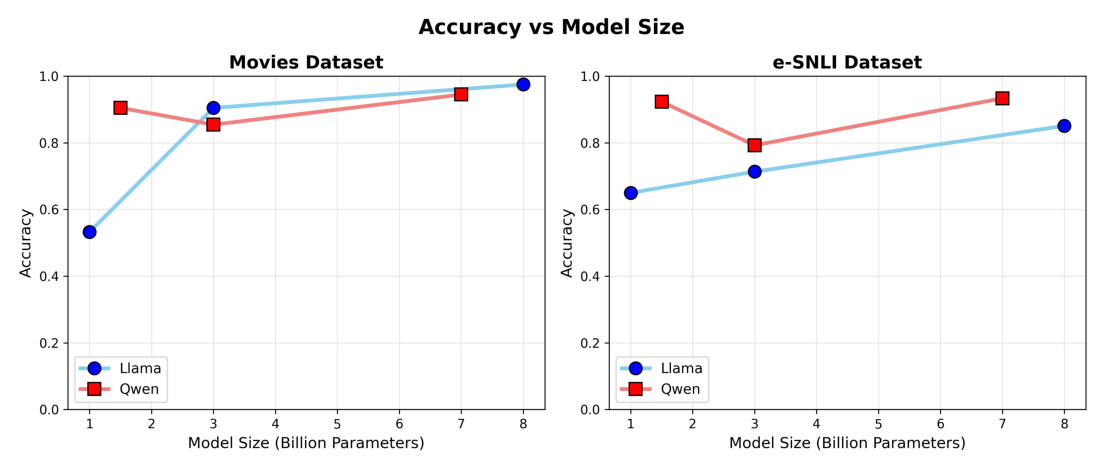

In [17]:
os.chdir(path+'/results')
img = mpimg.imread('classifiers_accuracy_vs_size.png')
plt.figure(figsize=(14, 14))
plt.imshow(img)
plt.axis('off')
plt.show()

# **1. COUNTERFACTUALS GENERATION**

### **Task: IMDB**

**Experiments:**

In [36]:
model = 'llama3-8b'
task = 'movies'
idx = random.randint(1, len(movies))
print_experiment_instance(path, task, model, idx)


EXPERIMENT: Introspection on IMDB

Printing instance with index 173

1. CLASSIFICATION
→ Prompt: You are a sentiment classifier. Answer only "positive" or "negative". Do not explain the answer. What is the sentiment of the user's paragraph? 
	  Paragraph: ( note : there are spoilers regarding the film 's climax ; the election , of course ) we see matthew broderick , a man torn to a primal state ; he 's been unfaithful to his wife , lied to and manipulated his students , and by the same token they 've demeaned his masculinity , his self - respect , his desperate attempt at changing the world . and yet , he equates the cause of his pain , his torment , with tracy flick ( reese witherspoon ) . no matter how many students have come and gone , and disappointed him as an educator , she 's the real threat . about to give in , and divulge that she 's won by only a lone vote , broderick 's mccalister turns in defeat , sees tracy 's euphoric celebration in the outside corridor and says , ' no '

**Evaluation:**

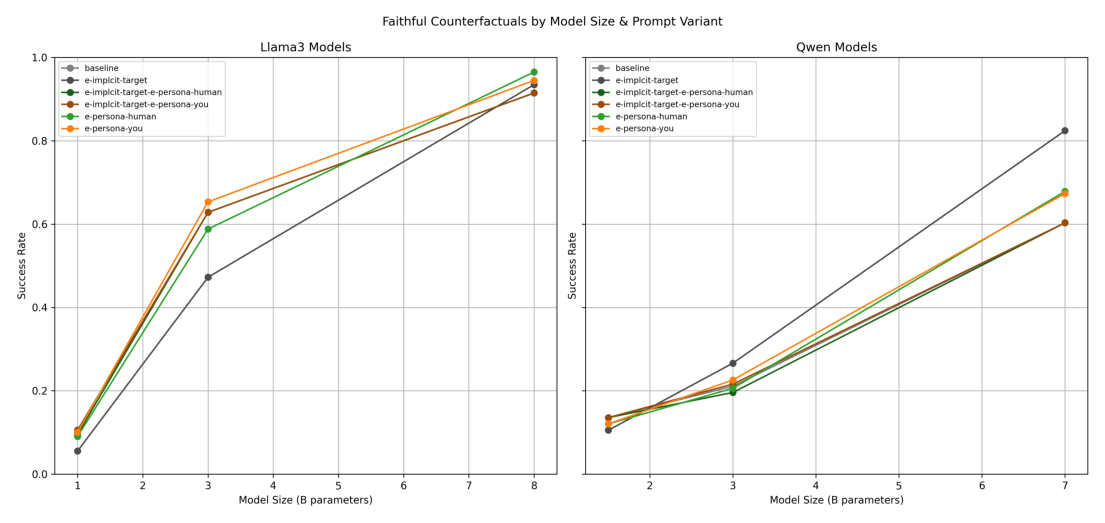

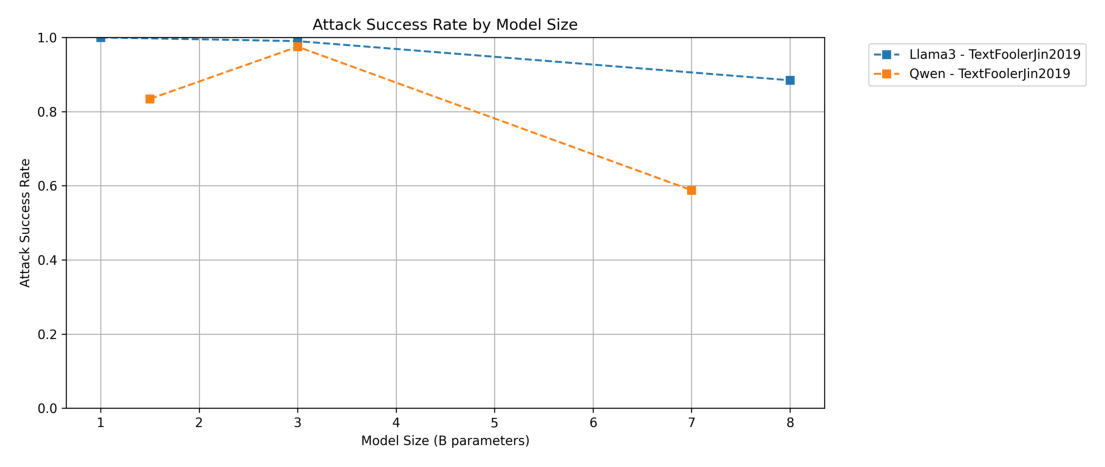

In [37]:
plotsDir = path + '/results/movie_results/plots'
plots = ['Introspection_Success.png', 'Attack_Success.png']

for plot in plots:
    img = mpimg.imread(plotsDir+'/'+plot)
    plt.figure(figsize=(14,10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

### **Task: e-SNLI**

**Experiment:**

In [49]:
model = 'llama3-3b'
task = 'esnli'
idx = random.randint(0, len(esnli))
print_experiment_instance(path, task, model, idx)


EXPERIMENT: Introspection on e-Snli

Printing instance with index 2946

1. CLASSIFICATION
→ Prompt: You are an entailment classifier. Does the statement "A large audience is seated inside together." entail from the following paragraph? Answer either "yes" for entailment or "no" for no entailment. Do not explain the answer. 
	  Paragraph: A large audience of people seated at banquet tables is watching the happenings on a stage surrounded by blue curtains.
→ Classification: NO

2. ADVERSARIAL ATTACK (TextFoolerJin)
→ Perturbed Text:  A large [[audiences]] of people seated at banquet tables is watching the happenings on a stage surrounded by blue curtains
Result: 1 → 0 Status: Successful

3. COUNTERFACTUAL GENERATION
• Variant: e-implcit-target e-persona-human
  Prompt:  The task is entailment classification and the statement "A large audience is seated inside together." does not entail the user's paragraph. Generate a counterfactual explanation by making minimal changes to the paragraph

**Evaluation:**

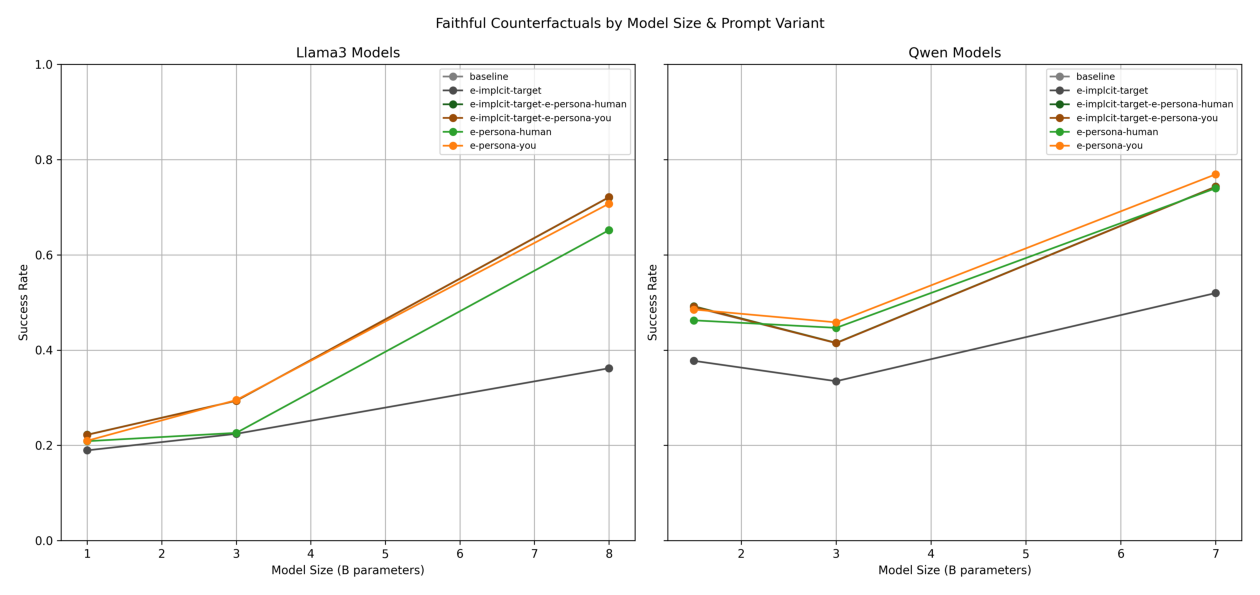

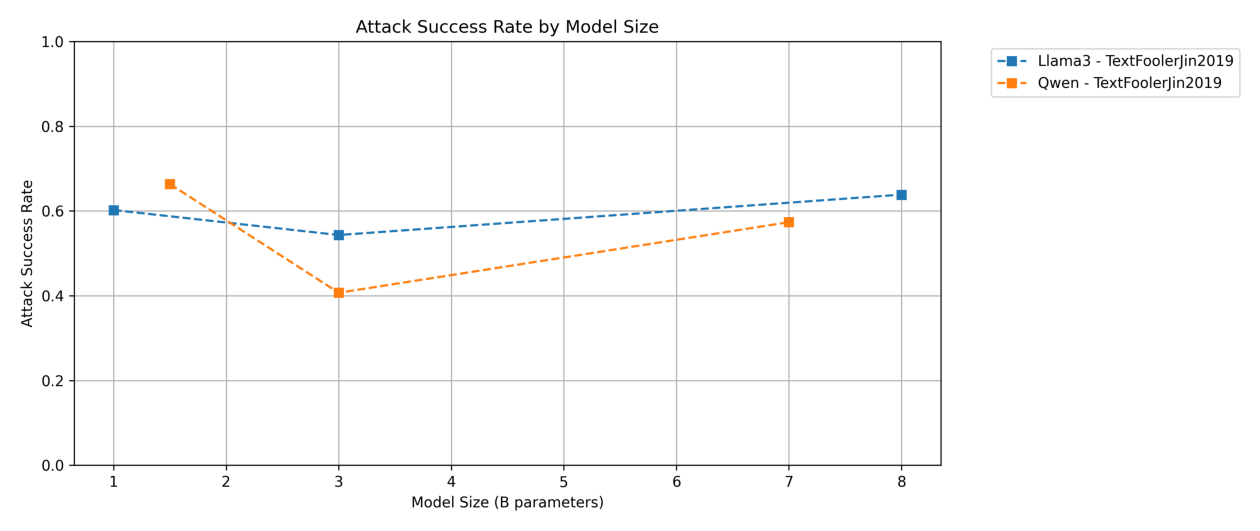

In [41]:
plotsDir = path + '/results/esnli_results/plots'
plots = ['Introspection_Success.png', 'Attack_Success.png']

for plot in plots:
    img = mpimg.imread(plotsDir+'/'+plot)
    plt.figure(figsize=(16,12))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# **2. QUALITY EVALUATION**

### **Task: IMDB**

**Experiment:**

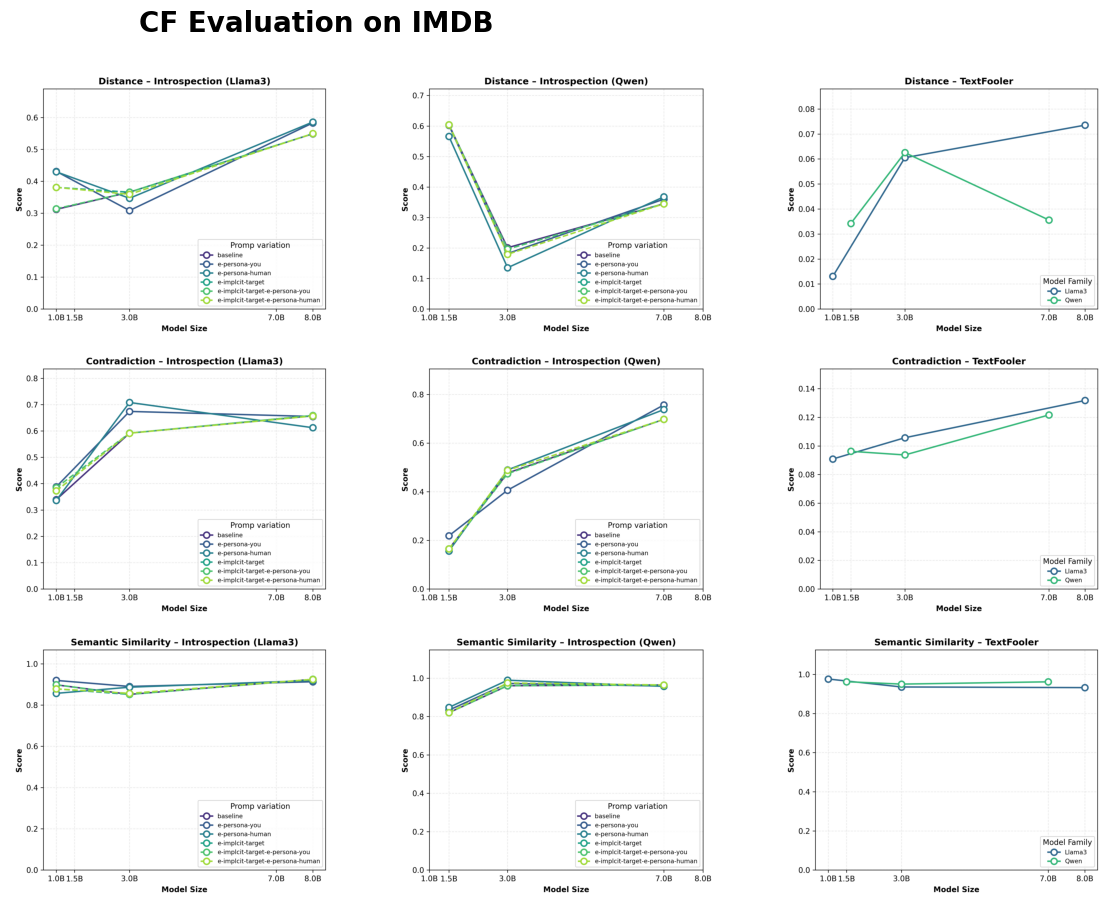

In [45]:
metrics = ['distance', 'contradiction', 'semantic_similarity']
model_families = ['Llama3', 'Qwen']
plotsDir = path + '/results/movie_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("CF Evaluation on IMDB", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()


### **Task: e-SNLI**

**Experiment:**

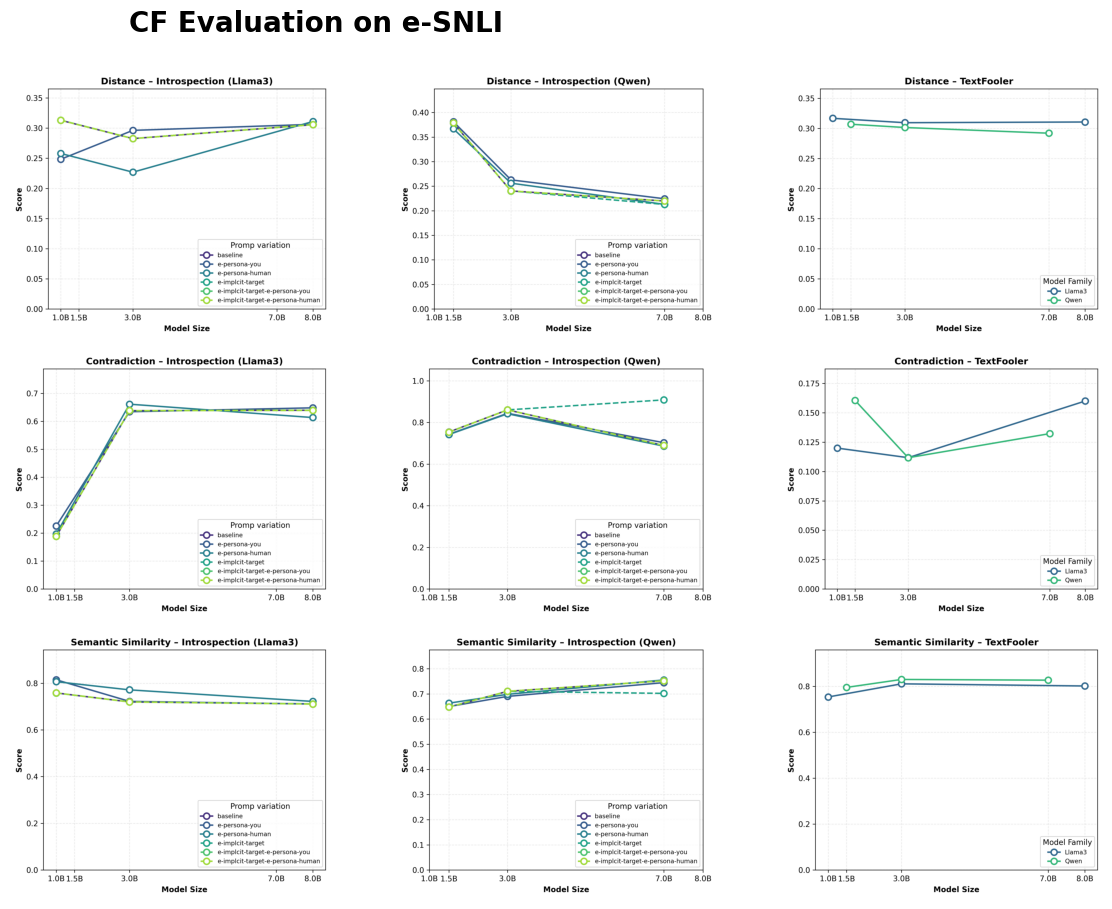

In [46]:
metrics = ['distance', 'contradiction', 'semantic_similarity']
model_families = ['Llama3', 'Qwen']
plotsDir = path + '/results/esnli_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("CF Evaluation on e-SNLI", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()

#**Counterfactual Edits Against Human-Annotated Feature Importance**

- **True Positive (TP)** — a token that was **deleted, replaced, or inserted** *and* lies **inside** a human-annotated evidence span.  
- **False Positive (FP)** — a token that was **deleted, replaced, or inserted** but lies **outside** any human-annotated evidence span.  
- **False Negative (FN)** — a token that lies **inside** a human-annotated evidence span but was **not** deleted, replaced, or inserted.



**Precision**: What percent of the perturbations in the input are *evidence* supported?

 $$
\text{Precision} = \frac{T_P}{T_P + F_P}
$$

**Recall**: What percent of the *human evidence spans* are covered by the perturbations in the input?  

$$
\text{Recall} = \frac{T_P}{T_P + F_N}
$$


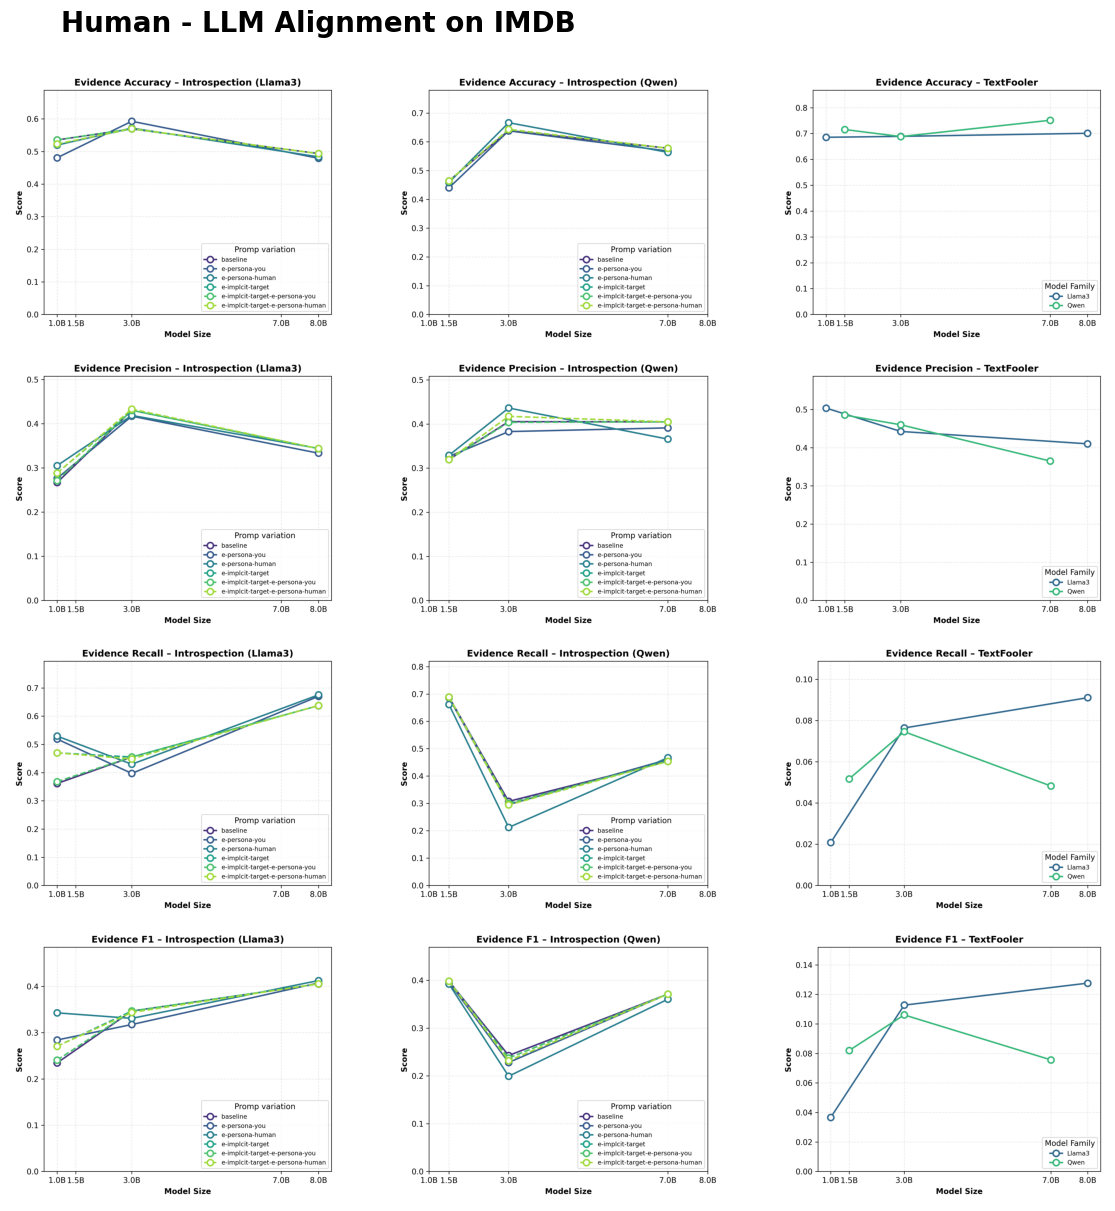

In [47]:
metrics = ['evidence_accuracy', 'evidence_precision', 'evidence_recall', 'evidence_f1']
model_families = ['Llama3', 'Qwen']
plotsDir = path + '/results/movie_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("Human - LLM Alignment on IMDB", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()

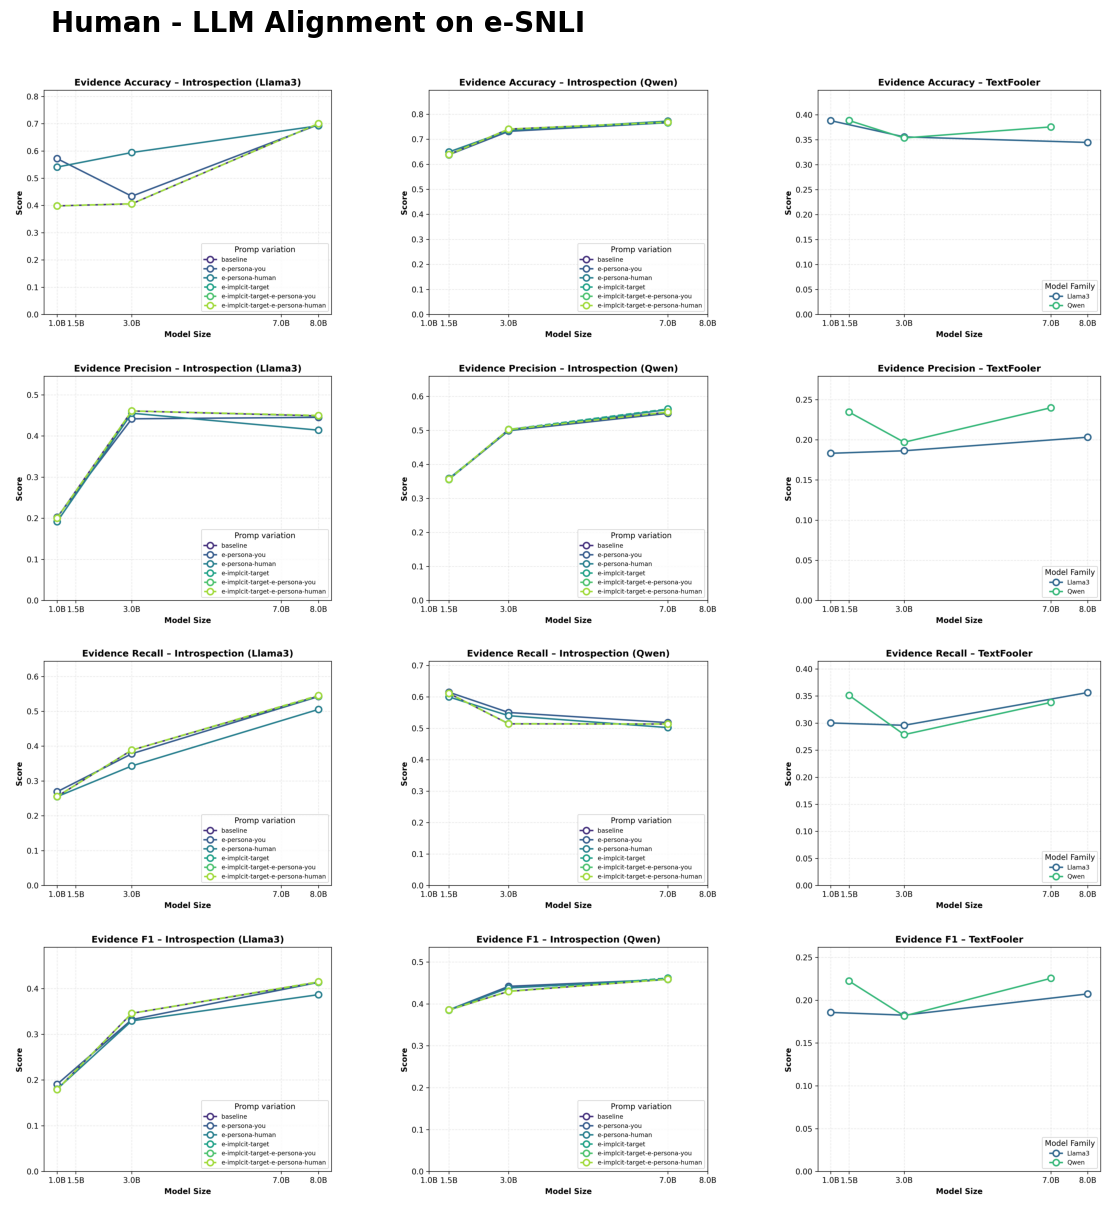

In [48]:
metrics = ['evidence_accuracy', 'evidence_precision', 'evidence_recall', 'evidence_f1']
model_families = ['Llama3', 'Qwen']
plotsDir = path + '/results/esnli_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("Human - LLM Alignment on e-SNLI", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()